In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
book = pd.read_csv("resources/round1/prices_round_1_day_0.csv", sep=";")
trades = pd.read_csv("resources/round1/trades_round_1_day_0.csv", sep=";")

trades = trades.rename(columns={"symbol": "product"})

In [23]:
merged = book.merge(
    trades[["timestamp", "product", "price", "quantity"]],
    on=["timestamp", "product"],
    how="left"
)

In [24]:
merged

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,price,quantity
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0,NaN,NaN
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0,NaN,NaN
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0,NaN,NaN
3,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0,NaN,NaN
4,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0,12007.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20000,0,999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0,NaN,NaN
20001,0,999800,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,24.0,NaN,NaN,13007.0,0.0,NaN,NaN
20002,0,999800,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10018.0,27.0,NaN,NaN,NaN,NaN,10018.0,0.0,NaN,NaN
20003,0,999900,ASH_COATED_OSMIUM,9998.0,21.0,NaN,NaN,NaN,NaN,10016.0,12.0,10019.0,21.0,NaN,NaN,10007.0,0.0,NaN,NaN


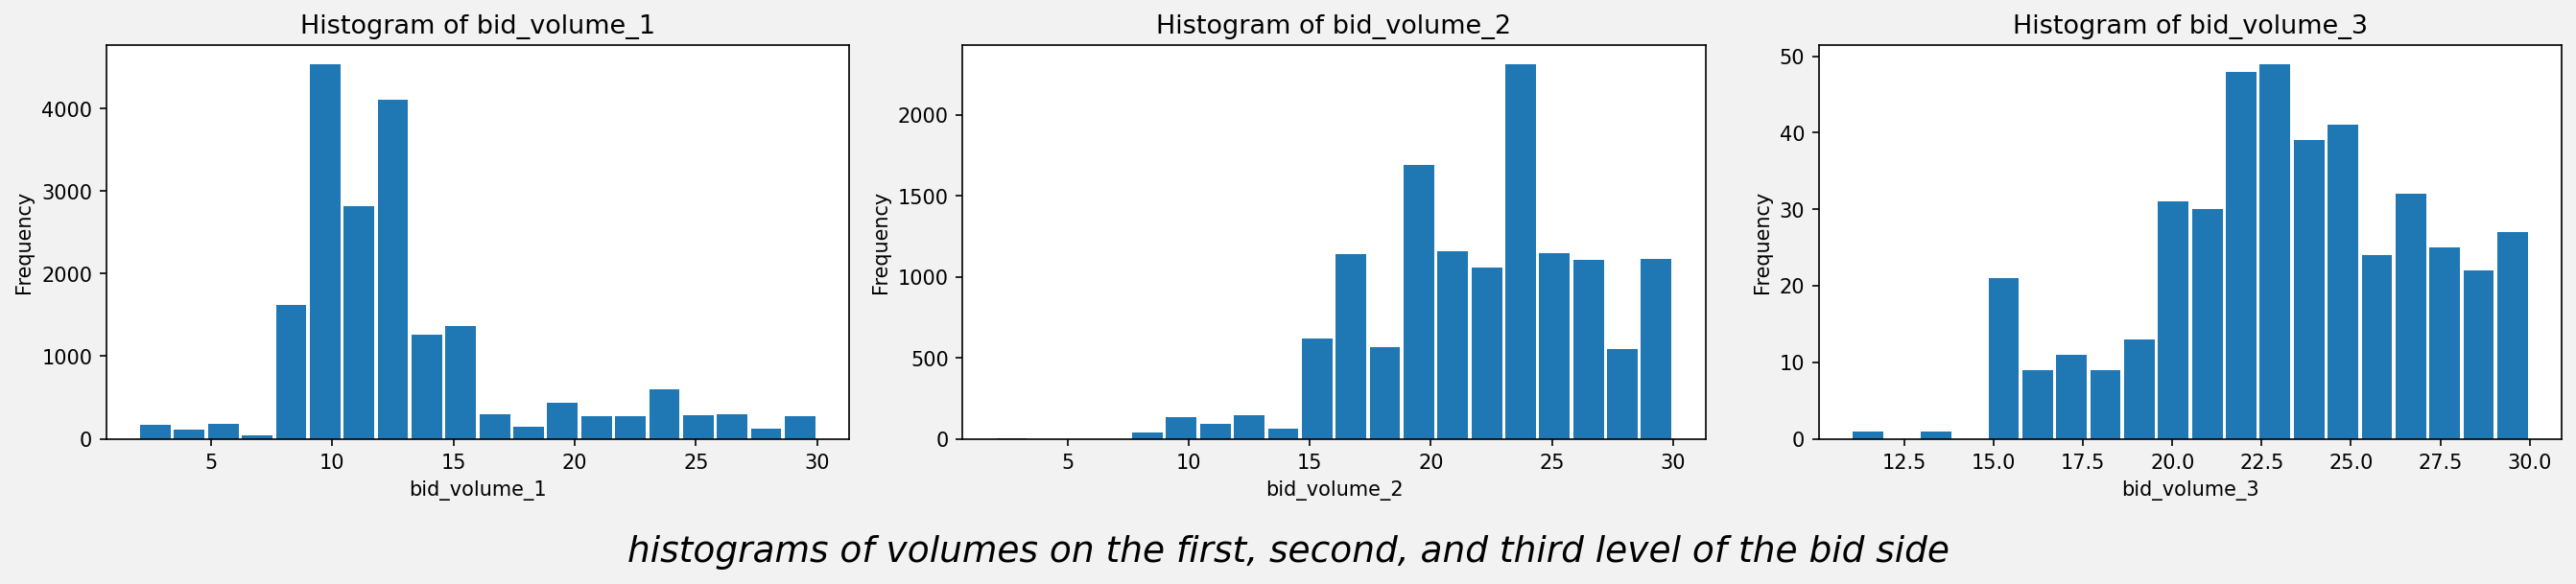

In [25]:
cols = ["bid_volume_1", "bid_volume_2", "bid_volume_3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor="#f2f2f2", dpi=150)

for ax, col in zip(axes, cols):
    ax.hist(merged[col].dropna(), bins=20, rwidth=0.9)
    ax.set_title(f"Histogram of {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.text(
    0.5, 0.01,
    "histograms of volumes on the first, second, and third level of the bid side",
    ha="center",
    fontsize=18,
    style="italic"
)

plt.show()

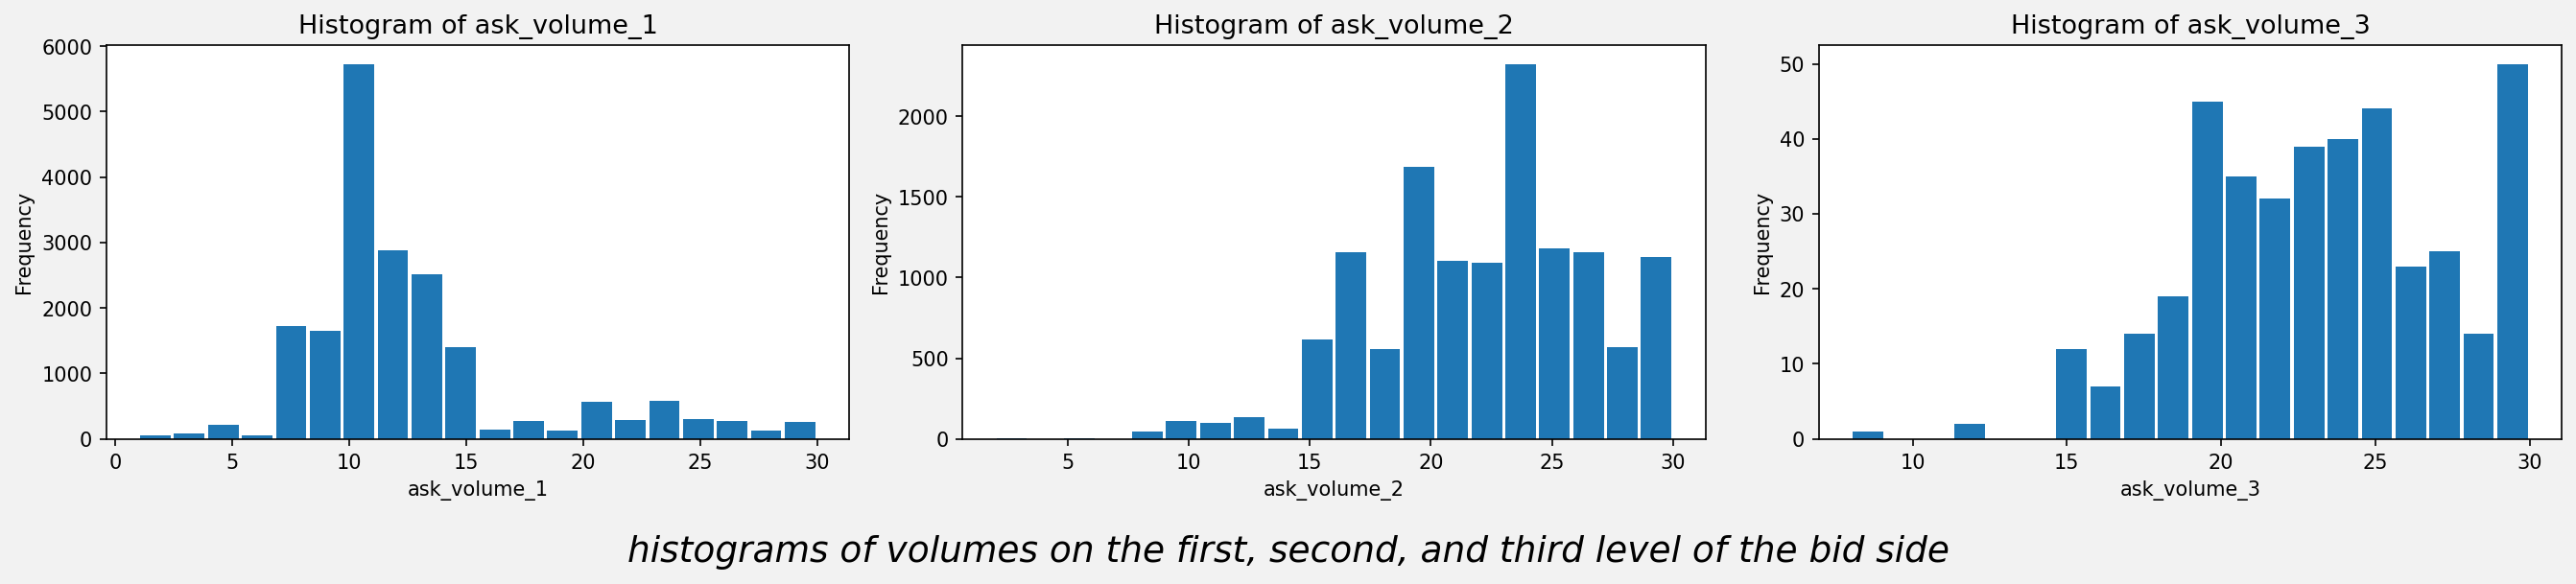

In [26]:
cols = ["ask_volume_1", "ask_volume_2", "ask_volume_3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor="#f2f2f2", dpi=150)

for ax, col in zip(axes, cols):
    ax.hist(merged[col].dropna(), bins=20, rwidth=0.9)
    ax.set_title(f"Histogram of {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.text(
    0.5, 0.01,
    "histograms of volumes on the first, second, and third level of the bid side",
    ha="center",
    fontsize=18,
    style="italic"
)

plt.show()

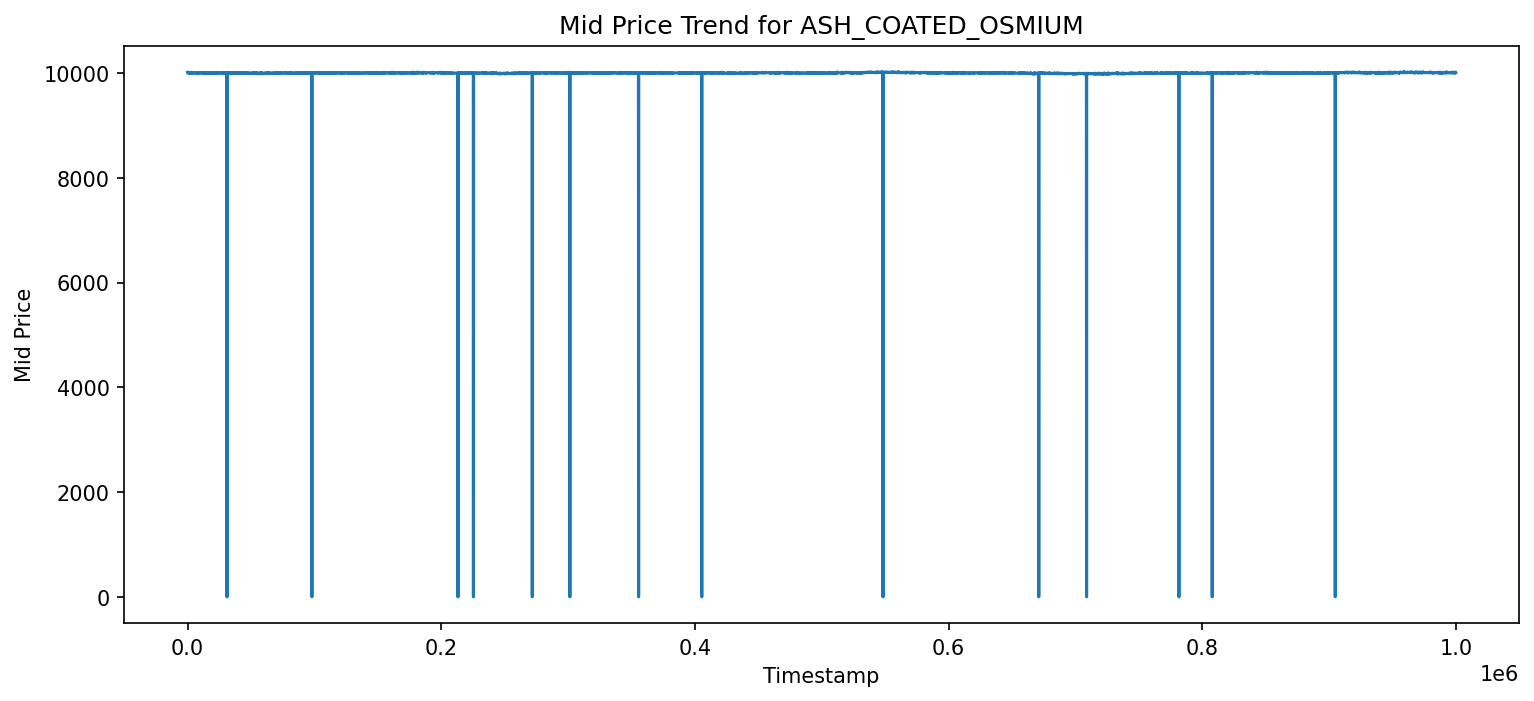

In [28]:
product_df = merged[merged["product"] == "ASH_COATED_OSMIUM"].copy()

plt.figure(figsize=(12, 5), dpi=150)
plt.plot(product_df["timestamp"], product_df["mid_price"])
plt.title("Mid Price Trend for ASH_COATED_OSMIUM")
plt.xlabel("Timestamp")
plt.ylabel("Mid Price")
plt.show()

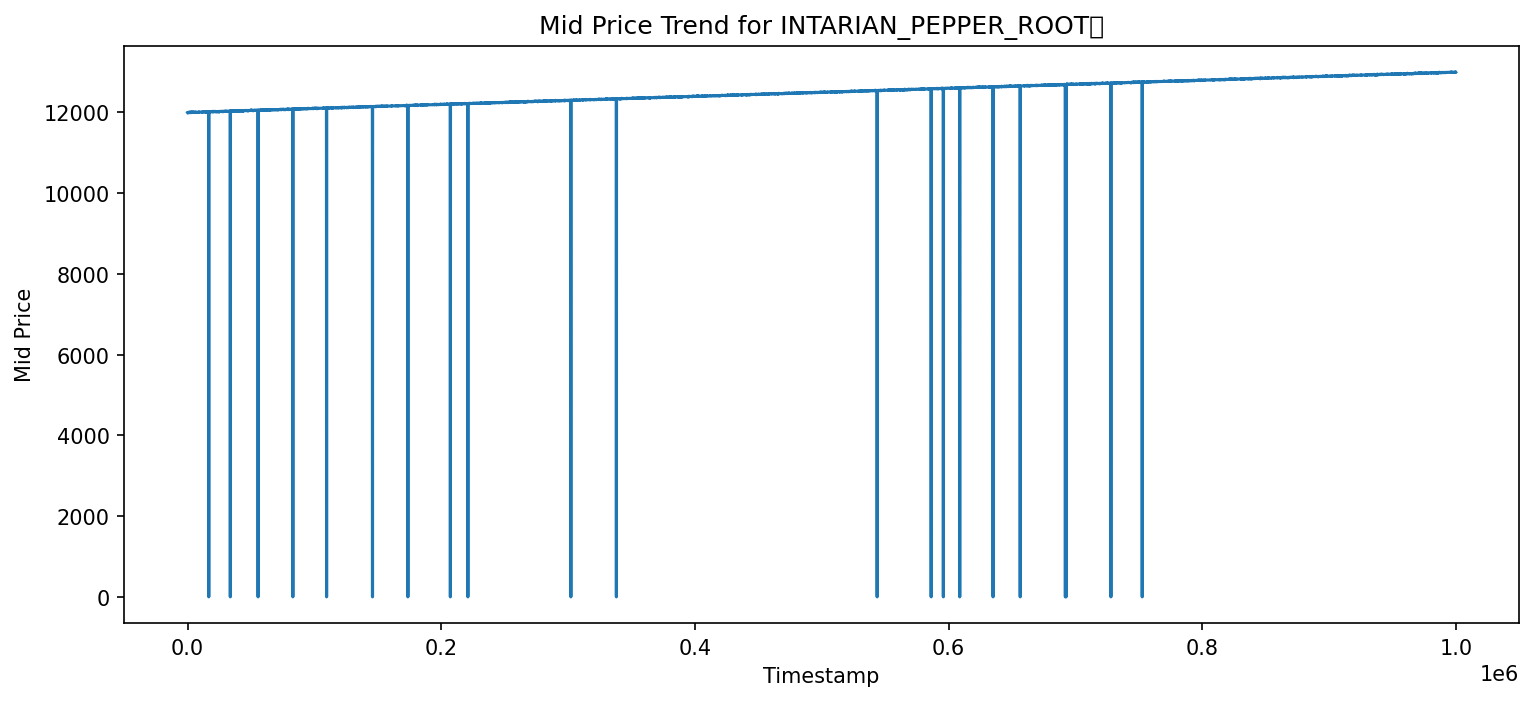

In [30]:
product_df = merged[merged["product"] == "INTARIAN_PEPPER_ROOT"].copy()

plt.figure(figsize=(12, 5), dpi=150)
plt.plot(product_df["timestamp"], product_df["mid_price"])
plt.title("Mid Price Trend for INTARIAN_PEPPER_ROOT	")
plt.xlabel("Timestamp")
plt.ylabel("Mid Price")
plt.show()

In [31]:
product_df = merged[(merged["product"] == "INTARIAN_PEPPER_ROOT") & (merged["mid_price"] > 0)].copy()
product_df["fair_value"] = product_df["mid_price"].rolling(50, min_periods=1).mean()

In [32]:
product_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,price,quantity,fair_value
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0,NaN,NaN,11998.500000
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0,NaN,NaN,11999.500000
4,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0,12007.0,5.0,11999.333333
7,0,300,INTARIAN_PEPPER_ROOT,11994.0,10.0,11991.0,24.0,NaN,NaN,12007.0,10.0,NaN,NaN,NaN,NaN,12000.5,0.0,NaN,NaN,11999.625000
9,0,400,INTARIAN_PEPPER_ROOT,11994.0,12.0,11991.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11994.0,0.0,NaN,NaN,11998.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,0,999500,INTARIAN_PEPPER_ROOT,12989.0,19.0,NaN,NaN,NaN,NaN,13006.0,12.0,NaN,NaN,NaN,NaN,12997.5,0.0,NaN,NaN,12997.000000
19997,0,999600,INTARIAN_PEPPER_ROOT,12993.0,8.0,NaN,NaN,NaN,NaN,13007.0,8.0,13010.0,25.0,NaN,NaN,13000.0,0.0,NaN,NaN,12997.100000
20000,0,999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0,NaN,NaN,12997.160000
20001,0,999800,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,24.0,NaN,NaN,13007.0,0.0,NaN,NaN,12997.400000


In [34]:
class PepperRootDebugger:
    def __init__(
        self,
        default_fair_value=12000,
        alpha=0.2,
        edge=2,
        passive_size=8,
        take_size=12,
        position_limit=50,
        position_step=10,
    ):
        self.default_fair_value = default_fair_value
        self.alpha = alpha
        self.edge = edge
        self.passive_size = passive_size
        self.take_size = take_size
        self.position_limit = position_limit
        self.position_step = position_step

        self.fair_value = default_fair_value
        self.position = 0
        self.cash = 0
        self.history = []

    def update_ewma(self, mid_price):
        self.fair_value = self.alpha * mid_price + (1 - self.alpha) * self.fair_value
        return self.fair_value

    def step(self, row):
        best_bid = row["bid_price_1"]
        best_ask = row["ask_price_1"]
        mid_price = row["mid_price"]

        fair_value = self.update_ewma(mid_price)

        buy_capacity = max(0, self.position_limit - self.position)
        sell_capacity = max(0, self.position_limit + self.position)

        inventory_skew = self.position // self.position_step
        passive_bid = round(fair_value - self.edge - inventory_skew)
        passive_ask = round(fair_value + self.edge - inventory_skew)

        buy_order = 0
        sell_order = 0
        buy_fill = 0
        sell_fill = 0

        # simple aggressive rules
        if best_ask <= fair_value - self.edge and buy_capacity > 0:
            buy_order = min(self.take_size, buy_capacity, -row["ask_volume_1"])
            self.position += buy_order
            self.cash -= buy_order * best_ask
            buy_fill = buy_order

        if best_bid >= fair_value + self.edge and sell_capacity > 0:
            sell_order = min(self.take_size, sell_capacity, row["bid_volume_1"])
            self.position -= sell_order
            self.cash += sell_order * best_bid
            sell_fill = sell_order

        mtm_pnl = self.cash + self.position * mid_price

        self.history.append({
            "timestamp": row["timestamp"],
            "mid_price": mid_price,
            "fair_value": fair_value,
            "best_bid": best_bid,
            "best_ask": best_ask,
            "passive_bid": passive_bid,
            "passive_ask": passive_ask,
            "buy_fill": buy_fill,
            "sell_fill": sell_fill,
            "position": self.position,
            "cash": self.cash,
            "pnl": mtm_pnl,
        })

In [35]:
df = merged.copy()

pepper = df[df["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper = pepper[pepper["mid_price"] > 0].reset_index(drop=True)

sim = PepperRootDebugger()

for _, row in pepper.iterrows():
    sim.step(row)

debug_df = pd.DataFrame(sim.history)
debug_df.head()

,timestamp,mid_price,fair_value,best_bid,best_ask,passive_bid,passive_ask,buy_fill,sell_fill,position,cash,pnl
0,0,11998.5,11999.70000,11991.0,12006.0,11998,12002,0.0,0.0,0.0,0.0,0.0
1,100,12000.5,11999.86000,11994.0,12007.0,11998,12002,0.0,0.0,0.0,0.0,0.0
2,200,11999.0,11999.68800,11991.0,12007.0,11998,12002,0.0,0.0,0.0,0.0,0.0
3,300,12000.5,11999.85040,11994.0,12007.0,11998,12002,0.0,0.0,0.0,0.0,0.0
4,400,11994.0,11998.68032,11994.0,NaN,11997,12001,0.0,0.0,0.0,0.0,0.0


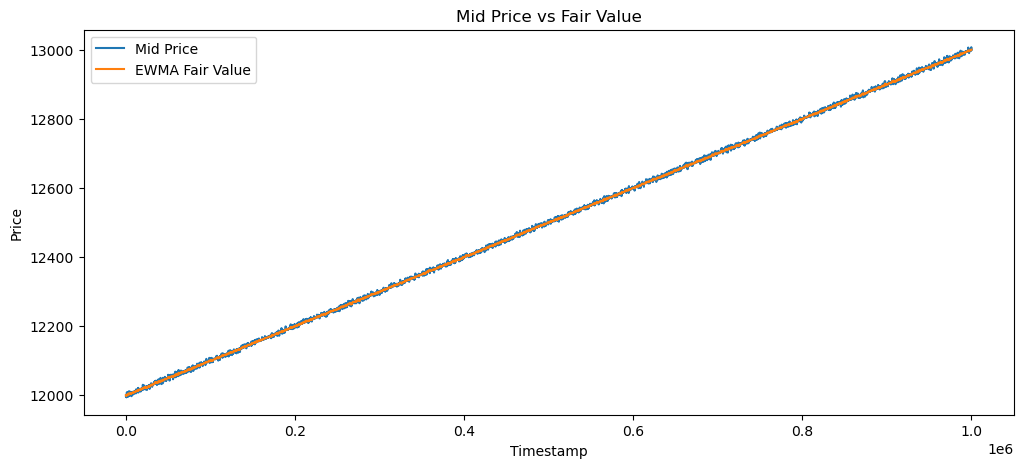

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(debug_df["timestamp"], debug_df["mid_price"], label="Mid Price")
plt.plot(debug_df["timestamp"], debug_df["fair_value"], label="EWMA Fair Value")
plt.legend()
plt.title("Mid Price vs Fair Value")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.show()

In [40]:
pepper = df[df["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper = pepper[pepper["mid_price"] > 0].copy()
pepper = pepper.sort_values("timestamp").reset_index(drop=True)

x = pepper["timestamp"].values
y = pepper["mid_price"].values

b, a = np.polyfit(x, y, 1)   # y ~= a + b*x
pepper["trend_fair"] = a + b * pepper["timestamp"]

print("intercept =", a)
print("slope =", b)

intercept = 11999.951810022014
slope = 0.0010000772056863228


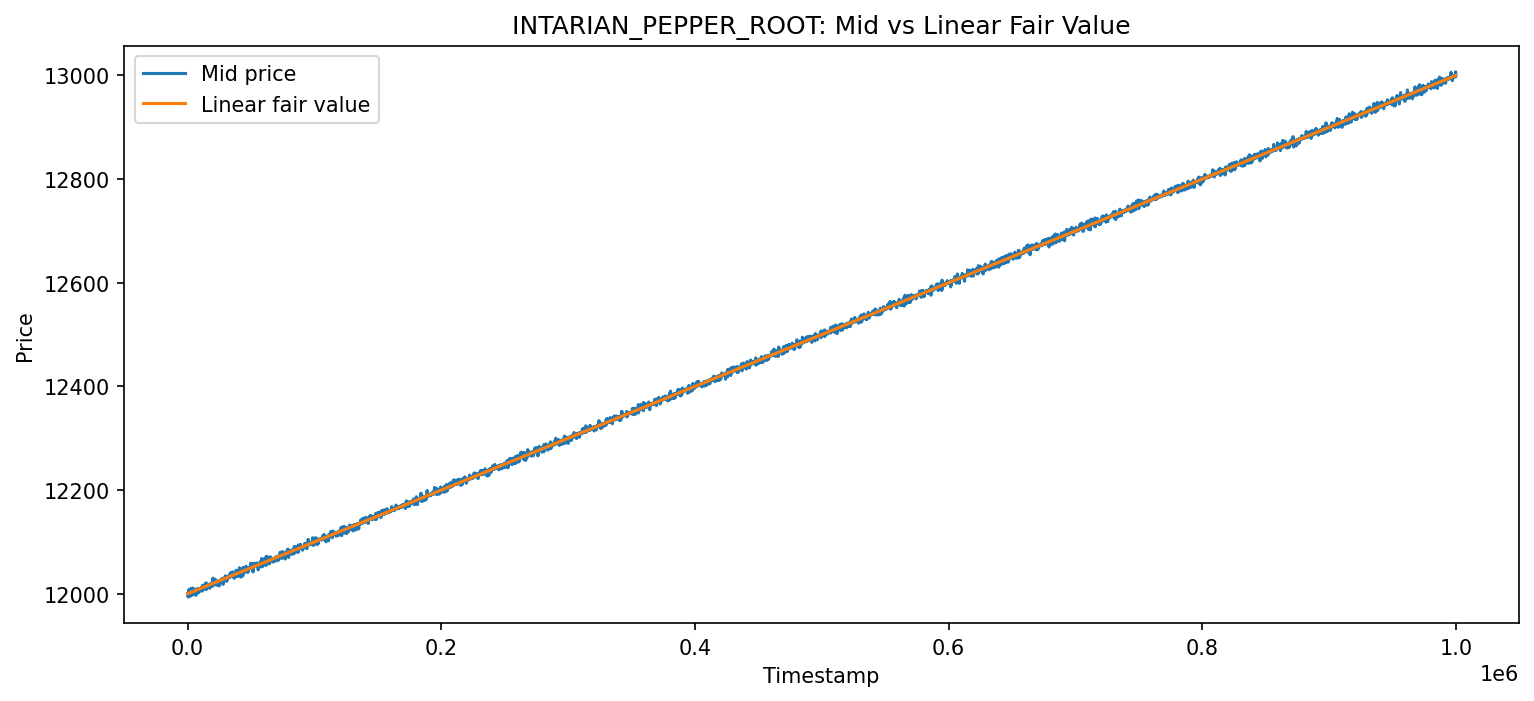

In [41]:
plt.figure(figsize=(12, 5), dpi=150)
plt.plot(pepper["timestamp"], pepper["mid_price"], label="Mid price")
plt.plot(pepper["timestamp"], pepper["trend_fair"], label="Linear fair value")
plt.title("INTARIAN_PEPPER_ROOT: Mid vs Linear Fair Value")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.show()

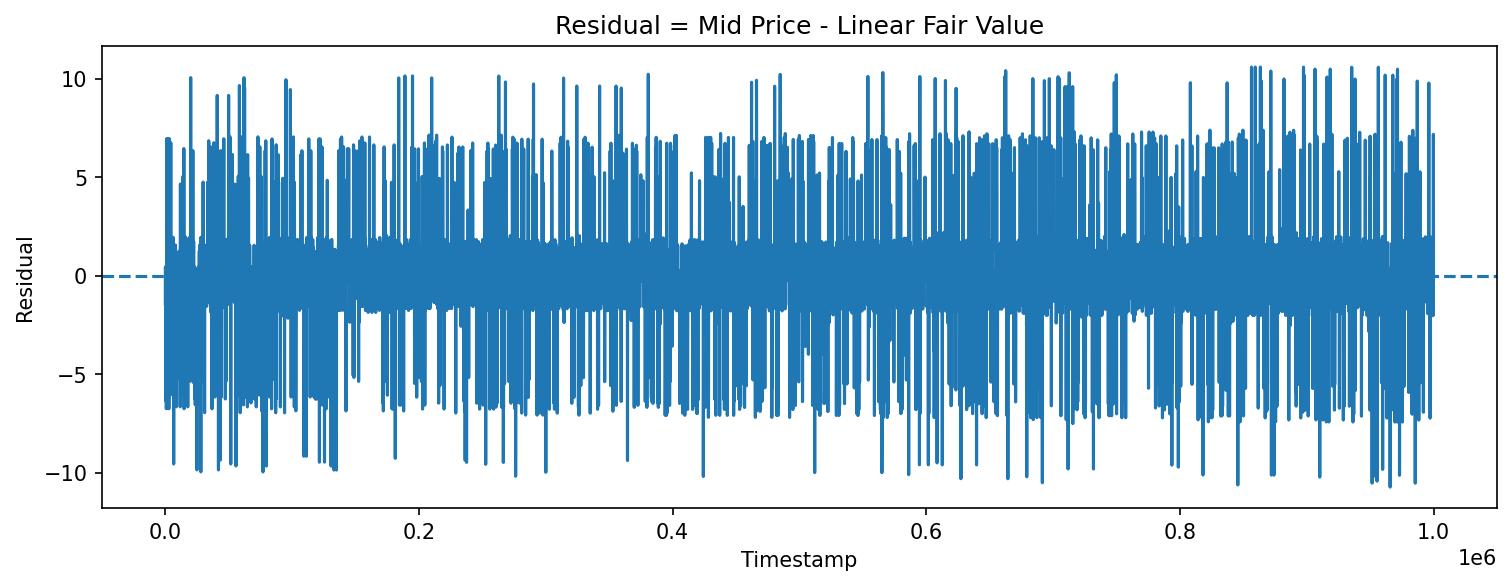

count    9.981000e+03
mean     1.512344e-11
std      2.360921e+00
min     -1.072637e+01
25%     -2.659232e-01
50%      7.502581e-03
75%      2.788824e-01
max      1.058207e+01
Name: residual, dtype: float64


In [42]:
pepper["residual"] = pepper["mid_price"] - pepper["trend_fair"]

plt.figure(figsize=(12, 4), dpi=150)
plt.plot(pepper["timestamp"], pepper["residual"])
plt.axhline(0, linestyle="--")
plt.title("Residual = Mid Price - Linear Fair Value")
plt.xlabel("Timestamp")
plt.ylabel("Residual")
plt.show()

print(pepper["residual"].describe())

In [43]:
horizon = 20
threshold = pepper["residual"].std()

pepper["future_mid"] = pepper["mid_price"].shift(-horizon)

buy_mask = pepper["residual"] <= -threshold
sell_mask = pepper["residual"] >= threshold

buy_edge = (pepper.loc[buy_mask, "future_mid"] - pepper.loc[buy_mask, "ask_price_1"]).dropna()
sell_edge = (pepper.loc[sell_mask, "bid_price_1"] - pepper.loc[sell_mask, "future_mid"]).dropna()

print("Num buy signals:", len(buy_edge))
print("Avg buy edge:", buy_edge.mean())

print("Num sell signals:", len(sell_edge))
print("Avg sell edge:", sell_edge.mean())

Num buy signals: 201
Avg buy edge: 4.975124378109452
Num sell signals: 168
Avg sell edge: 1.0119047619047619


In [ ]:
import json
from typing import Any, Optional

# from data import LIMITS
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState


class Logger:
    def __init__(self) -> None:
        self.logs = ""
        self.max_log_length = 3750

    def print(self, *objects: Any, sep: str = " ", end: str = "\n") -> None:
        self.logs += sep.join(map(str, objects)) + end

    def flush(self, state: TradingState, orders: dict[Symbol, list[Order]], conversions: int, trader_data: str) -> None:
        base_length = len(
            self.to_json(
                [
                    self.compress_state(state, ""),
                    self.compress_orders(orders),
                    conversions,
                    "",
                    "",
                ]
            )
        )

        max_item_length = (self.max_log_length - base_length) // 3

        print(
            self.to_json(
                [
                    self.compress_state(state, self.truncate(state.traderData, max_item_length)),
                    self.compress_orders(orders),
                    conversions,
                    self.truncate(trader_data, max_item_length),
                    self.truncate(self.logs, max_item_length),
                ]
            )
        )

        self.logs = ""

    def compress_state(self, state: TradingState, trader_data: str) -> list[Any]:
        return [
            state.timestamp,
            trader_data,
            self.compress_listings(state.listings),
            self.compress_order_depths(state.order_depths),
            self.compress_trades(state.own_trades),
            self.compress_trades(state.market_trades),
            state.position,
            self.compress_observations(state.observations),
        ]

    def compress_listings(self, listings: dict[Symbol, Listing]) -> list[list[Any]]:
        return [[listing.symbol, listing.product, listing.denomination] for listing in listings.values()]

    def compress_order_depths(self, order_depths: dict[Symbol, OrderDepth]) -> dict[Symbol, list[Any]]:
        return {
            symbol: [order_depth.buy_orders, order_depth.sell_orders]
            for symbol, order_depth in order_depths.items()
        }

    def compress_trades(self, trades: dict[Symbol, list[Trade]]) -> list[list[Any]]:
        compressed = []
        for arr in trades.values():
            for trade in arr:
                compressed.append(
                    [trade.symbol, trade.price, trade.quantity, trade.buyer, trade.seller, trade.timestamp]
                )
        return compressed

    def compress_observations(self, observations: Observation) -> list[Any]:
        conversion_observations = {}
        for product, observation in observations.conversionObservations.items():
            conversion_observations[product] = [
                observation.bidPrice,
                observation.askPrice,
                observation.transportFees,
                observation.exportTariff,
                observation.importTariff,
                observation.sugarPrice,
                observation.sunlightIndex,
            ]

        return [observations.plainValueObservations, conversion_observations]

    def compress_orders(self, orders: dict[Symbol, list[Order]]) -> list[list[Any]]:
        compressed = []
        for arr in orders.values():
            for order in arr:
                compressed.append([order.symbol, order.price, order.quantity])
        return compressed

    def to_json(self, value: Any) -> str:
        return json.dumps(value, cls=ProsperityEncoder, separators=(",", ":"))

    def truncate(self, value: str, max_length: int) -> str:
        lo, hi = 0, min(len(value), max_length)
        out = ""

        while lo <= hi:
            mid = (lo + hi) // 2

            candidate = value[:mid]
            if len(candidate) < len(value):
                candidate += "..."

            encoded_candidate = json.dumps(candidate)

            if len(encoded_candidate) <= max_length:
                out = candidate
                lo = mid + 1
            else:
                hi = mid - 1

        return out


logger = Logger()


class Trader:
    ASH_COATED_OSMIUM_LIMIT = 80
    ASH_COATED_OSMIUM_DEFAULT_FAIR_VALUE = 10000
    ASH_COATED_OSMIUM_POSITION_STEP = 15
    ASH_COATED_OSMIUM_PASSIVE_SIZE = 12
    ASH_COATED_OSMIUM_TAKE_SIZE = 20
    ASH_COATED_OSMIUM_TAKE_EDGE = 1
    ASH_COATED_OSMIUM_PASSIVE_OFFSET = 6
    ASH_COATED_OSMIUM_EMA_ALPHA = 0.1
    ASH_COATED_OSMIUM_ANCHOR_WEIGHT = 0.2
    ASH_COATED_OSMIUM_SOFT_POS = 30
    ASH_COATED_OSMIUM_HARD_POS = 50
    ASH_COATED_OSMIUM_THIN_BOOK_SPREAD = 8
    ASH_COATED_OSMIUM_THIN_BOOK_VOLUME = 8
    ASH_COATED_OSMIUM_THIN_BOOK_OFFSET_REDUCTION = 2
    ASH_COATED_OSMIUM_THIN_BOOK_SIZE_BOOST = 4

    INTARIAN_PEPPER_ROOT_LIMIT = 80
    INTARIAN_PEPPER_ROOT_DEFAULT_FAIR_VALUE = 12000
    INTARIAN_PEPPER_ROOT_WINDOW = 100
    INTARIAN_PEPPER_ROOT_TREND_THRESHOLD = 6
    INTARIAN_PEPPER_ROOT_TAKE_SIZE = 10
    INTARIAN_PEPPER_ROOT_EXIT_BUFFER = 2

    def get_best_bid(self, order_depth: OrderDepth) -> Optional[int]:
        return max(order_depth.buy_orders) if order_depth.buy_orders else None

    def get_best_ask(self, order_depth: OrderDepth) -> Optional[int]:
        return min(order_depth.sell_orders) if order_depth.sell_orders else None

    def get_mid_price(self, order_depth: OrderDepth, default_fair_value: int) -> int:
        best_bid = self.get_best_bid(order_depth)
        best_ask = self.get_best_ask(order_depth)

        if best_bid is not None and best_ask is not None:
            return round((best_bid + best_ask) / 2)
        if best_bid is not None:
            return best_bid
        if best_ask is not None:
            return best_ask
        return default_fair_value

    def get_microprice(self, order_depth: OrderDepth, default_fair_value: int) -> float:
        best_bid = self.get_best_bid(order_depth)
        best_ask = self.get_best_ask(order_depth)

        if best_bid is None or best_ask is None:
            return float(self.get_mid_price(order_depth, default_fair_value))

        bid_volume = order_depth.buy_orders.get(best_bid, 0)
        ask_volume = -order_depth.sell_orders.get(best_ask, 0)

        if bid_volume <= 0 or ask_volume <= 0:
            return float((best_bid + best_ask) / 2)

        return (best_bid * ask_volume + best_ask * bid_volume) / (bid_volume + ask_volume)

    def update_history(
        self,
        trader_data: dict,
        product: str,
        timestamp: int,
        mid_price: int,
        window: int,
    ) -> None:
        if "history" not in trader_data:
            trader_data["history"] = {}
        if product not in trader_data["history"]:
            trader_data["history"][product] = {"t": [], "p": []}

        trader_data["history"][product]["t"].append(timestamp)
        trader_data["history"][product]["p"].append(mid_price)

        trader_data["history"][product]["t"] = trader_data["history"][product]["t"][-window:]
        trader_data["history"][product]["p"] = trader_data["history"][product]["p"][-window:]

    def get_linear_fair_value(
        self,
        trader_data: dict,
        product: str,
        timestamp: int,
        default_fair_value: int,
    ) -> int:
        history = trader_data.get("history", {}).get(product, {})
        t = history.get("t", [])
        p = history.get("p", [])

        if len(t) < 5:
            return default_fair_value

        n = len(t)
        mean_t = sum(t) / n
        mean_p = sum(p) / n

        denom = sum((ti - mean_t) ** 2 for ti in t)
        if denom == 0:
            return round(mean_p)

        slope = sum((ti - mean_t) * (pi - mean_p) for ti, pi in zip(t, p)) / denom
        intercept = mean_p - slope * mean_t

        fair_value = intercept + slope * timestamp
        return round(fair_value)

    def trade_intarian_pepper_root(
        self,
        order_depth: OrderDepth,
        position: int,
        limit: int,
        timestamp: int,
        trader_data: dict,
    ) -> list[Order]:
        orders: list[Order] = []

        buy_capacity = max(0, limit - position)

        if order_depth.sell_orders and buy_capacity > 0:
            worst_ask = max(order_depth.sell_orders)
            orders.append(Order("INTARIAN_PEPPER_ROOT", worst_ask, buy_capacity))

        return orders

    def trade_ash_coated_osmium(
        self,
        order_depth: OrderDepth,
        position: int,
        limit: int,
        trader_data: dict,
    ) -> list[Order]:
        orders: list[Order] = []
        best_bid = self.get_best_bid(order_depth)
        best_ask = self.get_best_ask(order_depth)

        mid_price = self.get_mid_price(order_depth, self.ASH_COATED_OSMIUM_DEFAULT_FAIR_VALUE)

        if "ash_mid_ema" not in trader_data:
            trader_data["ash_mid_ema"] = mid_price
        else:
            trader_data["ash_mid_ema"] = (
                self.ASH_COATED_OSMIUM_EMA_ALPHA * mid_price
                + (1 - self.ASH_COATED_OSMIUM_EMA_ALPHA) * trader_data["ash_mid_ema"]
            )

        ema_fv = trader_data["ash_mid_ema"]
        fair_value = (
            self.ASH_COATED_OSMIUM_ANCHOR_WEIGHT * self.ASH_COATED_OSMIUM_DEFAULT_FAIR_VALUE
            + (1 - self.ASH_COATED_OSMIUM_ANCHOR_WEIGHT) * ema_fv
        )

        buy_capacity = max(0, limit - position)
        sell_capacity = max(0, limit + position)

        inventory_skew = position // self.ASH_COATED_OSMIUM_POSITION_STEP

        buy_edge = self.ASH_COATED_OSMIUM_TAKE_EDGE
        sell_edge = self.ASH_COATED_OSMIUM_TAKE_EDGE

        passive_bid_size = self.ASH_COATED_OSMIUM_PASSIVE_SIZE
        passive_ask_size = self.ASH_COATED_OSMIUM_PASSIVE_SIZE

        if position > self.ASH_COATED_OSMIUM_SOFT_POS:
            buy_edge += 3
            sell_edge = 1
            passive_bid_size = 4
            passive_ask_size = 16
        elif position < -self.ASH_COATED_OSMIUM_SOFT_POS:
            buy_edge = max(1, buy_edge - 1)
            sell_edge += 2
            passive_bid_size = 16
            passive_ask_size = 4

        passive_bid = round(fair_value - self.ASH_COATED_OSMIUM_PASSIVE_OFFSET - inventory_skew)
        passive_ask = round(fair_value + self.ASH_COATED_OSMIUM_PASSIVE_OFFSET - inventory_skew)

        if position >= self.ASH_COATED_OSMIUM_HARD_POS:
            if best_bid is not None and sell_capacity > 0:
                bid_volume = order_depth.buy_orders[best_bid]
                qty = min(bid_volume, sell_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
                if qty > 0:
                    orders.append(Order("ASH_COATED_OSMIUM", best_bid, -qty))
                    sell_capacity -= qty

            if best_bid is not None and best_ask is not None and sell_capacity > 0:
                reduce_ask = max(best_bid + 1, min(best_ask - 1, round(fair_value + 1 - inventory_skew)))
                if best_bid < reduce_ask < best_ask:
                    orders.append(Order("ASH_COATED_OSMIUM", reduce_ask, -min(10, sell_capacity)))
            return orders

        if position <= -self.ASH_COATED_OSMIUM_HARD_POS:
            if best_ask is not None and buy_capacity > 0:
                ask_volume = -order_depth.sell_orders[best_ask]
                qty = min(ask_volume, buy_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
                if qty > 0:
                    orders.append(Order("ASH_COATED_OSMIUM", best_ask, qty))
                    buy_capacity -= qty

            if best_bid is not None and best_ask is not None and buy_capacity > 0:
                reduce_bid = min(best_ask - 1, max(best_bid + 1, round(fair_value - 1 - inventory_skew)))
                if best_bid < reduce_bid < best_ask:
                    orders.append(Order("ASH_COATED_OSMIUM", reduce_bid, min(10, buy_capacity)))
            return orders

        if best_ask is not None and buy_capacity > 0 and best_ask <= fair_value - buy_edge:
            ask_volume = -order_depth.sell_orders[best_ask]
            qty = min(ask_volume, buy_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
            if position > self.ASH_COATED_OSMIUM_SOFT_POS:
                qty = min(qty, 8)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", best_ask, qty))
                buy_capacity -= qty

        if best_bid is not None and sell_capacity > 0 and best_bid >= fair_value + sell_edge:
            bid_volume = order_depth.buy_orders[best_bid]
            qty = min(bid_volume, sell_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
            if position < -self.ASH_COATED_OSMIUM_SOFT_POS:
                qty = min(qty, 8)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", best_bid, -qty))
                sell_capacity -= qty

        if best_bid is not None and best_ask is not None and buy_capacity > 0:
            if best_bid < passive_bid < best_ask:
                qty = min(passive_bid_size, buy_capacity)
                if qty > 0:
                    orders.append(Order("ASH_COATED_OSMIUM", passive_bid, qty))

        if best_bid is not None and best_ask is not None and sell_capacity > 0:
            if best_bid < passive_ask < best_ask:
                qty = min(passive_ask_size, sell_capacity)
                if qty > 0:
                    orders.append(Order("ASH_COATED_OSMIUM", passive_ask, -qty))

        return orders

    def run(self, state: TradingState):
        result: dict[Symbol, list[Order]] = {}

        if state.traderData:
            try:
                trader_data = json.loads(state.traderData)
            except Exception:
                trader_data = {}
        else:
            trader_data = {}

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)
            if product == "INTARIAN_PEPPER_ROOT":
                limit = self.INTARIAN_PEPPER_ROOT_LIMIT
            elif product == "ASH_COATED_OSMIUM":
                limit = self.ASH_COATED_OSMIUM_LIMIT
            else:
                limit = 0

            if product == "INTARIAN_PEPPER_ROOT":
                result[product] = self.trade_intarian_pepper_root(
                    order_depth,
                    position,
                    limit,
                    state.timestamp,
                    trader_data,
                )
            elif product == "ASH_COATED_OSMIUM":
                result[product] = self.trade_ash_coated_osmium(order_depth, position, limit, trader_data)
            else:
                result[product] = []

        conversions = 0
        trader_data_str = json.dumps(trader_data)
        logger.flush(state, result, conversions, trader_data_str)
        return result, conversions, trader_data_str

In [ ]:
import json
from typing import Any, Optional

# from data import LIMITS
from datamodel import Listing, Observation, Order, OrderDepth, ProsperityEncoder, Symbol, Trade, TradingState

class Logger:
    def __init__(self) -> None:
        self.logs = ""
        self.max_log_length = 3750

    def print(self, *objects: Any, sep: str = " ", end: str = "\n") -> None:
        self.logs += sep.join(map(str, objects)) + end

    def flush(self, state: TradingState, orders: dict[Symbol, list[Order]], conversions: int, trader_data: str) -> None:
        base_length = len(
            self.to_json(
                [
                    self.compress_state(state, ""),
                    self.compress_orders(orders),
                    conversions,
                    "",
                    "",
                ]
            )
        )

        max_item_length = (self.max_log_length - base_length) // 3

        print(
            self.to_json(
                [
                    self.compress_state(state, self.truncate(state.traderData, max_item_length)),
                    self.compress_orders(orders),
                    conversions,
                    self.truncate(trader_data, max_item_length),
                    self.truncate(self.logs, max_item_length),
                ]
            )
        )

        self.logs = ""

    def compress_state(self, state: TradingState, trader_data: str) -> list[Any]:
        return [
            state.timestamp,
            trader_data,
            self.compress_listings(state.listings),
            self.compress_order_depths(state.order_depths),
            self.compress_trades(state.own_trades),
            self.compress_trades(state.market_trades),
            state.position,
            self.compress_observations(state.observations),
        ]

    def compress_listings(self, listings: dict[Symbol, Listing]) -> list[list[Any]]:
        return [[listing.symbol, listing.product, listing.denomination] for listing in listings.values()]

    def compress_order_depths(self, order_depths: dict[Symbol, OrderDepth]) -> dict[Symbol, list[Any]]:
        return {
            symbol: [order_depth.buy_orders, order_depth.sell_orders]
            for symbol, order_depth in order_depths.items()
        }

    def compress_trades(self, trades: dict[Symbol, list[Trade]]) -> list[list[Any]]:
        compressed = []
        for arr in trades.values():
            for trade in arr:
                compressed.append(
                    [trade.symbol, trade.price, trade.quantity, trade.buyer, trade.seller, trade.timestamp]
                )
        return compressed

    def compress_observations(self, observations: Observation) -> list[Any]:
        conversion_observations = {}
        for product, observation in observations.conversionObservations.items():
            conversion_observations[product] = [
                observation.bidPrice,
                observation.askPrice,
                observation.transportFees,
                observation.exportTariff,
                observation.importTariff,
                observation.sugarPrice,
                observation.sunlightIndex,
            ]

        return [observations.plainValueObservations, conversion_observations]

    def compress_orders(self, orders: dict[Symbol, list[Order]]) -> list[list[Any]]:
        compressed = []
        for arr in orders.values():
            for order in arr:
                compressed.append([order.symbol, order.price, order.quantity])
        return compressed

    def to_json(self, value: Any) -> str:
        return json.dumps(value, cls=ProsperityEncoder, separators=(",", ":"))

    def truncate(self, value: str, max_length: int) -> str:
        lo, hi = 0, min(len(value), max_length)
        out = ""

        while lo <= hi:
            mid = (lo + hi) // 2

            candidate = value[:mid]
            if len(candidate) < len(value):
                candidate += "..."

            encoded_candidate = json.dumps(candidate)

            if len(encoded_candidate) <= max_length:
                out = candidate
                lo = mid + 1
            else:
                hi = mid - 1

        return out


logger = Logger()


class Trader:
    ASH_COATED_OSMIUM_LIMIT = 80
    ASH_COATED_OSMIUM_DEFAULT_FAIR_VALUE = 10000
    ASH_COATED_OSMIUM_POSITION_STEP = 20
    ASH_COATED_OSMIUM_PASSIVE_SIZE = 15
    ASH_COATED_OSMIUM_TAKE_SIZE = 16
    ASH_COATED_OSMIUM_TAKE_EDGE = 1
    ASH_COATED_OSMIUM_PASSIVE_OFFSET = 6

    INTARIAN_PEPPER_ROOT_LIMIT = 80
    INTARIAN_PEPPER_ROOT_DEFAULT_FAIR_VALUE = 12000
    INTARIAN_PEPPER_ROOT_WINDOW = 100
    INTARIAN_PEPPER_ROOT_TREND_THRESHOLD = 6
    INTARIAN_PEPPER_ROOT_TAKE_SIZE = 10
    INTARIAN_PEPPER_ROOT_EXIT_BUFFER = 2

    def get_best_bid(self, order_depth: OrderDepth) -> Optional[int]:
        return max(order_depth.buy_orders) if order_depth.buy_orders else None

    def get_best_ask(self, order_depth: OrderDepth) -> Optional[int]:
        return min(order_depth.sell_orders) if order_depth.sell_orders else None

    def get_mid_price(self, order_depth: OrderDepth, default_fair_value: int) -> int:
        best_bid = self.get_best_bid(order_depth)
        best_ask = self.get_best_ask(order_depth)

        if best_bid is not None and best_ask is not None:
            return round((best_bid + best_ask) / 2)
        if best_bid is not None:
            return best_bid
        if best_ask is not None:
            return best_ask
        return default_fair_value
    
    def update_history(
        self,
        trader_data: dict,
        product: str,
        timestamp: int,
        mid_price: int,
        window: int,
    ) -> None:
        if "history" not in trader_data:
            trader_data["history"] = {}
        if product not in trader_data["history"]:
            trader_data["history"][product] = {"t": [], "p": []}

        trader_data["history"][product]["t"].append(timestamp)
        trader_data["history"][product]["p"].append(mid_price)

        trader_data["history"][product]["t"] = trader_data["history"][product]["t"][-window:]
        trader_data["history"][product]["p"] = trader_data["history"][product]["p"][-window:]


    def get_linear_fair_value(
        self,
        trader_data: dict,
        product: str,
        timestamp: int,
        default_fair_value: int,
    ) -> int:
        history = trader_data.get("history", {}).get(product, {})
        t = history.get("t", [])
        p = history.get("p", [])

        if len(t) < 5:
            return default_fair_value

        n = len(t)
        mean_t = sum(t) / n
        mean_p = sum(p) / n

        denom = sum((ti - mean_t) ** 2 for ti in t)
        if denom == 0:
            return round(mean_p)

        slope = sum((ti - mean_t) * (pi - mean_p) for ti, pi in zip(t, p)) / denom
        intercept = mean_p - slope * mean_t

        fair_value = intercept + slope * timestamp
        return round(fair_value)

    def trade_intarian_pepper_root(
        self,
        order_depth: OrderDepth,
        position: int,
        limit: int,
        timestamp: int,
        trader_data: dict,
    ) -> list[Order]:
        orders: list[Order] = []

        buy_capacity = max(0, limit - position)

        if order_depth.sell_orders and buy_capacity > 0:
            worst_ask = max(order_depth.sell_orders)
            orders.append(Order("INTARIAN_PEPPER_ROOT", worst_ask, buy_capacity))

        return orders

    def trade_ash_coated_osmium(
        self,
        order_depth: OrderDepth,
        position: int,
        limit: int,
    ) -> list[Order]:
        orders: list[Order] = []
        best_bid = self.get_best_bid(order_depth)
        best_ask = self.get_best_ask(order_depth)
        fair_value = self.ASH_COATED_OSMIUM_DEFAULT_FAIR_VALUE

        buy_capacity = max(0, limit - position)
        sell_capacity = max(0, limit + position)

        inventory_skew = position // self.ASH_COATED_OSMIUM_POSITION_STEP
        passive_bid = fair_value - self.ASH_COATED_OSMIUM_PASSIVE_OFFSET - inventory_skew
        passive_ask = fair_value + self.ASH_COATED_OSMIUM_PASSIVE_OFFSET - inventory_skew

        # add this block
        buy_edge = self.ASH_COATED_OSMIUM_TAKE_EDGE
        sell_edge = self.ASH_COATED_OSMIUM_TAKE_EDGE

        if position > 20:
            buy_edge = 4   # harder to buy more when already long
            sell_edge = 1  # easier to sell and reduce long
        elif position < -20:
            buy_edge = 1   # easier to buy back when already short
            sell_edge = 4  # harder to sell more when already short

        if best_ask is not None and buy_capacity > 0 and best_ask <= fair_value - buy_edge:
            ask_volume = -order_depth.sell_orders[best_ask]
            qty = min(ask_volume, buy_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", best_ask, qty))
                buy_capacity -= qty

        if best_bid is not None and sell_capacity > 0 and best_bid >= fair_value + sell_edge:
            bid_volume = order_depth.buy_orders[best_bid]
            qty = min(bid_volume, sell_capacity, self.ASH_COATED_OSMIUM_TAKE_SIZE)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", best_bid, -qty))
                sell_capacity -= qty

        if best_bid is not None and best_ask is not None and buy_capacity > 0 and passive_bid > best_bid and passive_bid < best_ask:
            qty = min(self.ASH_COATED_OSMIUM_PASSIVE_SIZE, buy_capacity)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", passive_bid, qty))

        if best_bid is not None and best_ask is not None and sell_capacity > 0 and passive_ask < best_ask and passive_ask > best_bid:
            qty = min(self.ASH_COATED_OSMIUM_PASSIVE_SIZE, sell_capacity)
            if qty > 0:
                orders.append(Order("ASH_COATED_OSMIUM", passive_ask, -qty))

        return orders

    def run(self, state: TradingState):
        result: dict[Symbol, list[Order]] = {}

        if state.traderData:
            try:
                trader_data = json.loads(state.traderData)
            except Exception:
                trader_data = {}
        else:
            trader_data = {}

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)
            if product == "INTARIAN_PEPPER_ROOT":
                limit = self.INTARIAN_PEPPER_ROOT_LIMIT
            elif product == "ASH_COATED_OSMIUM":
                limit = self.ASH_COATED_OSMIUM_LIMIT
            else:
                limit = 0

            if product == "INTARIAN_PEPPER_ROOT":
                result[product] = self.trade_intarian_pepper_root(
                    order_depth,
                    position,
                    limit,
                    state.timestamp,
                    trader_data,
                )
            elif product == "ASH_COATED_OSMIUM":
                result[product] = self.trade_ash_coated_osmium(order_depth, position, limit)
            else:
                result[product] = []

        conversions = 0
        trader_data_str = json.dumps(trader_data)
        logger.flush(state, result, conversions, trader_data_str)
        return result, conversions, trader_data_str